# Simple Morphological Tree Examples

This notebook introduces the basic `mmcfilters` workflow on a small synthetic image and then repeats the same ideas on a real coin image.


## 1. Install the library

This notebook is a compact tour of the main `mmcfilters` workflow: build a morphological tree, compute attributes, filter connected components, and project the result back to an image.


In [1]:
!pip install mmcfilters
!pip install bokeh
!pip install morphotreeviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 29.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mmcfilters: filename=mmcfilters-0.1.19-cp312-cp312-linux_x86_64.whl size=388169 sha256=fd6d094b0591ffcc1e87fd431ff713457ae9e633b23bf3774abb1f5e936aee73
  Stored in directory: /root/.cache/pip/wheels/88/67/9e/16f9533e55ed3002eff335814a64f227d4b5de03d0e8c541f3
Successfully built mmcfilters
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00


## 2. Import the library


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import mmcfilters
import mtviz as viz
if not hasattr(viz, "show_level_sets"):
    viz.show_level_sets = getattr(viz, "showLevelSets", lambda *args, **kwargs: None)
from bokeh.io import output_notebook, show
from bokeh.layouts import column, row
output_notebook()


def create_component_tree(image, is_maxtree, radius=1.5):
    if is_maxtree:
        return mmcfilters.WeightedMorphologicalTree.createMaxTree(image, radius=radius)
    return mmcfilters.WeightedMorphologicalTree.createMinTree(image, radius=radius)


def print_tree_with_attribute(attribute_type, attribute_by_node):
    return lambda tree, node_id: f"id:{node_id}, {attribute_type.name}: {attribute_by_node[node_id]}"


def show_component_tree(tree, image=None, label=None):
    label = label or (lambda tree, node_id: f"id:{node_id}")

    def walk(node_id, depth=0):
        print("  " * depth + label(tree, node_id))
        for child_id in tree.getChildren(node_id):
            walk(child_id, depth + 1)

    if image is not None:
        plt.figure(figsize=(5, 5))
        plt.imshow(image, cmap='gray', vmax=255, vmin=0)
        plt.axis('off')
        plt.show()

    walk(tree.getRoot())


def show_tree(tree, label=None):
    show_component_tree(tree, label=label)


def getPlotTree(tree, title):
    show_component_tree(tree)
    return None


Loading BokehJS ...

## 3. Create a morphological tree from an input image

A component tree represents connected level sets as nodes. In this example, the synthetic image is small enough that the tree structure can be printed and compared with the pixel values.


In [19]:
#input_image = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)

input_image = np.array([
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203,203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203],
        [203,203, 78, 78,126,126,126,126,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203,203, 54, 54,203,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203, 54, 54, 54, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203, 54, 54, 54, 80, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126, 78, 78, 78, 78, 78, 78, 78, 78, 78,203, 54, 80, 54, 54, 54,203],
        [203, 78, 78, 78,126, 38, 38,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126,126, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203,203, 54, 80, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203, 54, 54, 54, 54, 54,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203,203, 54, 54, 54,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,126,126,126,126,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,126,126,126,126,126,126, 72,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78,161,161,161, 78, 78,203,126,126,126,126,126,126, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78,203,126,126,126,126,126, 72, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78,203,203,126,126,126, 72, 72, 72, 72, 72,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 90, 30,161, 78, 78,203,126,126, 72, 72, 72, 72, 72, 72, 72,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,126,126,126,126,126,126,126,203,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,203,203,126,126,126,126,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203],
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203]
], dtype=np.uint8)
(num_rows, num_cols) = input_image.shape

is_max_tree = False
tree = create_component_tree(input_image, is_max_tree)
Type = mmcfilters.Attribute.Type

viz.show_level_sets(input_image)


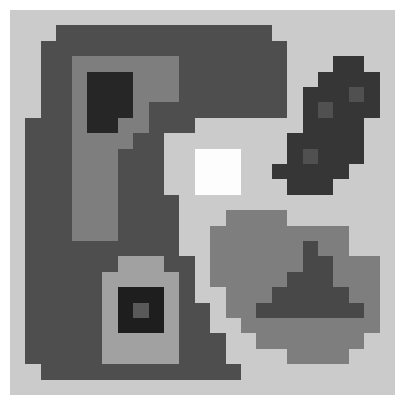

id:0
  id:1
    id:2
      id:3
        id:7
        id:10
      id:5
        id:11
    id:4
      id:8
    id:6
      id:9


In [20]:
show_component_tree(tree, image=input_image)

## 4. Available attributes

Attributes summarize geometric, radiometric, or topological properties of each node. Listing the available attributes is a good first step before choosing a filtering criterion.


In [21]:
describe = {}
for attribute_name, attribute_value in Type.__dict__.items():
    if(str(attribute_value).startswith("Type.")):
        describe[str(attribute_value).split('.')[1]] = mmcfilters.Attribute.describe(attribute_value)

df = pd.DataFrame(describe.items(), columns=['Attribute type', 'Description'])
df.style.set_caption("<H3><b>Available attributes</b></H3>")

,Attribute type,Description
0,AREA,Area: Number of pixels in the connected component.
1,VOLUME,"Volume: Sum of the gray-level intensities of all pixels in the connected component. Interpreted as the total mass under the component, or the integral of the image function over its support."
2,RELATIVE_VOLUME,Relative volume: Sum of differences between the node level and the gray-levels of pixels in the component. Measures the amount of intensity required to fill the component to its node level.
3,LEVEL,Level: Gray-level at which the connected component appears in the threshold decomposition hierarchy; corresponds to the altitude of the node in the component tree.
4,GRAY_HEIGHT,"GRAY_HEIGHT: For a node in the max-tree, the difference between its level and the maximum level among its descendants; analogously, in the min-tree, the difference to the minimum level among its descendants."
5,MEAN_LEVEL,Mean level: Average gray-level intensity of the pixels in the connected component.
6,VARIANCE_LEVEL,Variance of level: Variance of the gray-level values of the pixels in the connected component.
7,BOX_WIDTH,Bounding box width: Width of the minimum rectangle enclosing the connected component.
8,BOX_HEIGHT,Bounding box height: Height of the minimum rectangle enclosing the connected component.
9,RECTANGULARITY,Rectangularity: Ratio between the connected component area and the area of its bounding box. Values closer to 1 indicate shapes that efficiently fill their bounding box.


## 5. Compute a single attribute

`computeSingleAttribute` returns one value per tree node. The gray-height attribute is used here because it is easy to inspect on the printed tree.


In [22]:
Type = mmcfilters.Attribute.Type

attribute_type = Type.GRAY_HEIGHT
attribute_by_node = mmcfilters.Attribute.computeSingleAttribute(tree, attribute_type)

print(f"{attribute_type.name} (numpy): {attribute_by_node}")

GRAY_HEIGHT (numpy): [224. 174. 132.  89.  55.  61.  27.   0.   0.   0.   0.   0.]


In [23]:
show_tree(tree, print_tree_with_attribute(attribute_type, attribute_by_node))

id:0, GRAY_HEIGHT: 224.0
  id:1, GRAY_HEIGHT: 174.0
    id:2, GRAY_HEIGHT: 132.0
      id:3, GRAY_HEIGHT: 89.0
        id:7, GRAY_HEIGHT: 0.0
        id:10, GRAY_HEIGHT: 0.0
      id:5, GRAY_HEIGHT: 61.0
        id:11, GRAY_HEIGHT: 0.0
    id:4, GRAY_HEIGHT: 55.0
      id:8, GRAY_HEIGHT: 0.0
    id:6, GRAY_HEIGHT: 27.0
      id:9, GRAY_HEIGHT: 0.0


## 6. Compute multiple attributes

`computeAttributes` evaluates several attributes together and returns a node-by-attribute table. This is useful when a filter or analysis combines multiple criteria.


In [24]:
Type = mmcfilters.Attribute.Type

attribute_indices, attribute_matrix = mmcfilters.Attribute.computeAttributes(tree, [Type.AREA, Type.GRAY_HEIGHT, Type.VOLUME, Type.RELATIVE_VOLUME])
#print(attribute_matrix[:, attribute_indices['GRAY_HEIGHT']])
pd.DataFrame(attribute_matrix, columns=attribute_indices, index=pd.Index(range(len(attribute_matrix)), name="NodeID"))

,AREA,VOLUME,RELATIVE_VOLUME,GRAY_HEIGHT
NodeID,,,,
0,625.0,82872.0,77409.0,224.0
1,616.0,80595.0,45984.0,174.0
2,277.0,24802.0,20535.0,132.0
3,244.0,20608.0,10582.0,89.0
4,84.0,9612.0,1074.0,55.0
5,9.0,330.0,497.0,61.0
6,38.0,2130.0,983.0,27.0
7,191.0,14898.0,191.0,0.0
8,18.0,1296.0,18.0,0.0


## 7. Attribute filtering

Attribute filters remove or preserve nodes according to a criterion and then reconstruct an image from the modified tree. This example uses the subtractive rule with the gray-height values.


Text(0.5, 1.0, 'attribute filter')

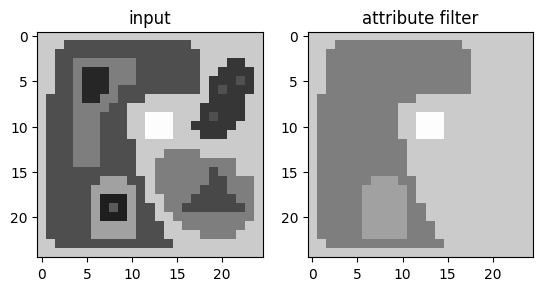

In [25]:
attribute_by_node = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT)
threshold = 80

attribute_filter = mmcfilters.AttributeFilters(tree)
filtered_image = attribute_filter.filteringSubtractiveRule(attribute_by_node > threshold)

plt.subplot(1,2, 1)
plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,2, 2)
plt.imshow(filtered_image.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')

## 8. Extract extinction values

Extinction values rank extrema by the importance of the attribute that disappears when components merge. They are often more stable than a fixed threshold on raw attribute values.


In [26]:
attribute_by_node = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT) # the attribute must be increasing

Regional extremum (leaf): 7
Extinction value:  3.4028234663852886e+38
Persistence node where the regional extremum still exists: 0
The regional extremum disappears at: 0

Regional extremum (leaf): 11
Extinction value:  61.0
Persistence node where the regional extremum still exists: 5
The regional extremum disappears at: 2

Regional extremum (leaf): 8
Extinction value:  55.0
Persistence node where the regional extremum still exists: 4
The regional extremum disappears at: 1

Regional extremum (leaf): 9
Extinction value:  27.0
Persistence node where the regional extremum still exists: 6
The regional extremum disappears at: 1

Regional extremum (leaf): 10
Extinction value:  0.0
Persistence node where the regional extremum still exists: 10
The regional extremum disappears at: 3



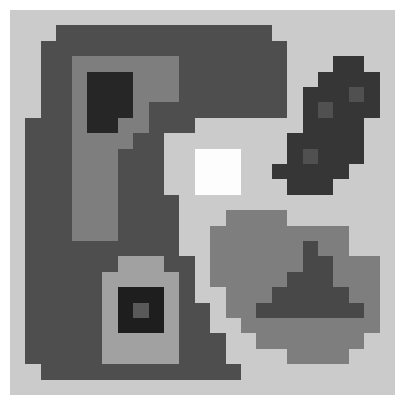

id:0
  id:1
    id:2
      id:3
        id:7
        id:10
      id:5
        id:11
    id:4
      id:8
    id:6
      id:9


In [27]:
extinction_values = mmcfilters.ExtinctionValues(tree, attribute_by_node)
for leaf_id, cutoff_node_id, extinction in extinction_values.getExtinctionValues():
    print("Regional extremum (leaf):", leaf_id)
    print("Extinction value: ", extinction)
    print("Persistence node where the regional extremum still exists:", cutoff_node_id)
    print("The regional extremum disappears at:", tree.getNodeParent(cutoff_node_id))
    print()

show_component_tree(tree, image=input_image)


## 9. Filter by extinction values

Here the filter keeps only the most relevant extrema according to the extinction ranking. This provides a compact way to control the number of preserved structures.


Text(0.5, 1.0, 'keeping 3 regional extrema')

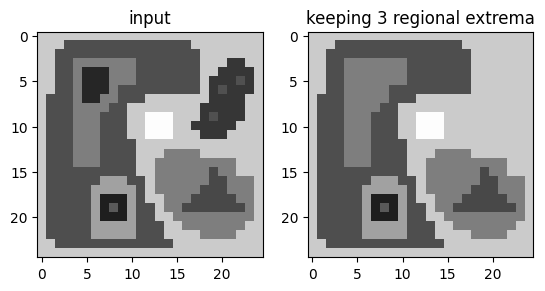

In [28]:
attribute_by_node = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT)
attribute_filter = mmcfilters.AttributeFilters(tree)

num_leaves_to_keep = 3 # keep num_leaves_to_keep leaves with the highest extinction values
filtered_image = attribute_filter.filteringByExtinction(attribute_by_node, num_leaves_to_keep)

plt.subplot(1,2, 1)
plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,2, 2)
plt.imshow(filtered_image, cmap='gray', vmax=255, vmin=0)
plt.title('keeping 3 regional extrema')

## 10. Work with the coin image

The same workflow is applied to a real image: direct attribute filtering, extinction-value filtering, and saliency-map construction.


Text(0.5, 1.0, 'attribute filter')

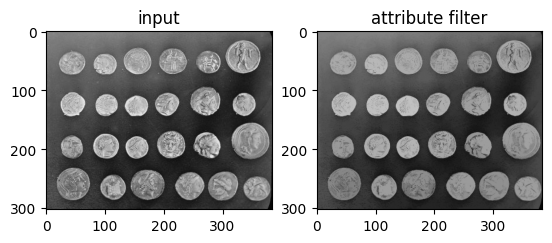

In [29]:
# 1. Filtering

from skimage import data, img_as_float
input_image = data.coins()
(num_rows, num_cols) = input_image.shape

is_max_tree = True
tree = create_component_tree(input_image, is_max_tree)

attribute_by_node = mmcfilters.Attribute.computeSingleAttribute(tree, Type.AREA)
threshold = 500

attribute_filter = mmcfilters.AttributeFilters(tree)
filtered_image = attribute_filter.filteringSubtractiveRule(attribute_by_node > threshold)

plt.subplot(1,2, 1)
plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,2, 2)
plt.imshow(filtered_image, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')

Text(0.5, 1.0, 'keeping 24 regional extrema')

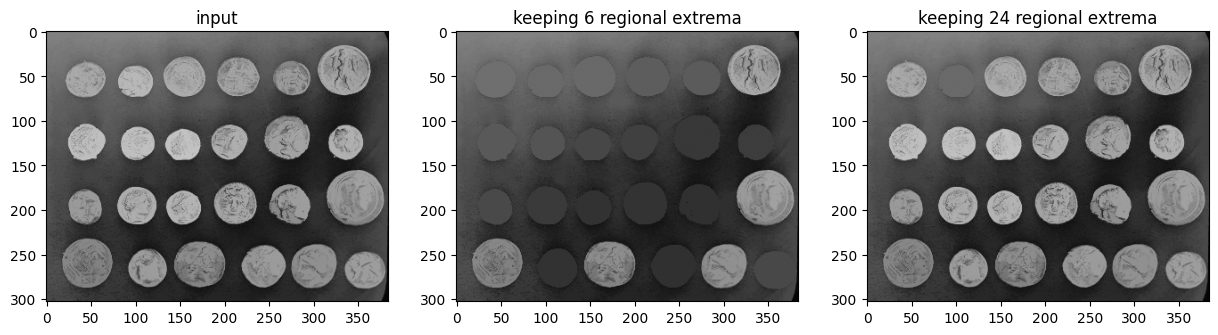

In [30]:
# 2. Filtering by extinction values

input_image = filtered_image

is_max_tree = True
tree = create_component_tree(input_image, is_max_tree)
attribute_filter = mmcfilters.AttributeFilters(tree)
attribute_by_node = mmcfilters.Attribute.computeSingleAttribute(tree, Type.AREA)

num_leaves_to_keep = 6 # keep num_leaves_to_keep leaves with the highest extinction values
filtered_image_6 = attribute_filter.filteringByExtinction(attribute_by_node, num_leaves_to_keep)

num_leaves_to_keep = 24 # keep num_leaves_to_keep leaves with the highest extinction values
filtered_image_24 = attribute_filter.filteringByExtinction(attribute_by_node, num_leaves_to_keep)

plt.figure(figsize=(15, 5))
plt.subplot(1,3, 1)
plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,3, 2)
plt.imshow(filtered_image_6, cmap='gray', vmax=255, vmin=0)
plt.title('keeping 6 regional extrema')

plt.subplot(1,3,3)
plt.imshow(filtered_image_24, cmap='gray', vmax=255, vmin=0)
plt.title('keeping 24 regional extrema')

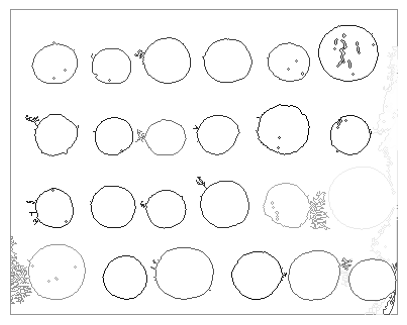

In [31]:
# 3. Creating a saliency map

attribute_by_node = mmcfilters.Attribute.computeSingleAttribute(tree, Type.AREA)
circularity = mmcfilters.Attribute.computeSingleAttribute(tree, Type.CIRCULARITY)
extinction_values = mmcfilters.ExtinctionValues(tree, attribute_by_node) # the attribute must be increasing
num_leaves_to_keep = int(tree.numLeafNodes * 1) # 5% of the regional extrema

contours = mmcfilters.ContourComputation.extraction(tree)

contour_image = np.zeros((num_rows*num_cols), dtype=np.float32)
importance = num_leaves_to_keep
for leaf_id, cutoff_node_id, extinction in sorted(extinction_values.getExtinctionValues(), key=lambda x: x[2], reverse=True)[:num_leaves_to_keep]:
    for p in contours.getContour(cutoff_node_id):
        contour_image[p]= circularity[cutoff_node_id]
        #contour_image[p]= importance
    importance -= 1


plt.figure(figsize=(5, 5))
plt.imshow(contour_image.reshape(num_rows, num_cols), cmap='Grays')
plt.axis('off')
plt.show()


## 11. Combine shape criteria on contours

This final section uses area and circularity to build contour-based saliency maps. The approach is limited to increasing attributes, so the chosen criteria should be checked before reuse.


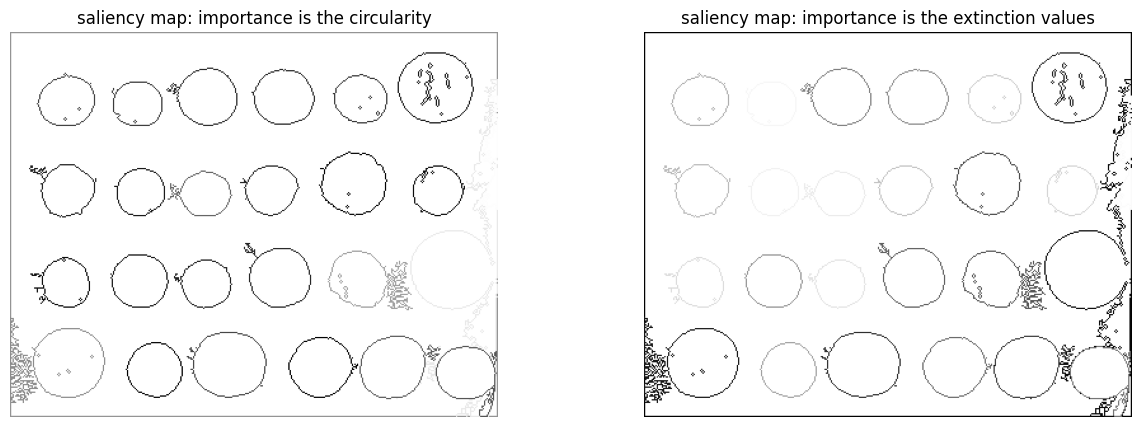

In [32]:
attribute_by_node = mmcfilters.Attribute.computeSingleAttribute(tree, Type.AREA)
circularity = mmcfilters.Attribute.computeSingleAttribute(tree, Type.CIRCULARITY)
extinction_values = mmcfilters.ExtinctionValues(tree, attribute_by_node) # the attribute must be increasing
num_leaves_to_keep = int(tree.numLeafNodes * 1)

contours = mmcfilters.ContourComputation.extraction(tree)

contour_image = np.zeros((num_rows*num_cols), dtype=np.float32)
importance = num_leaves_to_keep
for leaf_id, cutoff_node_id, extinction in sorted(extinction_values.getExtinctionValues(), key=lambda x: x[2], reverse=True)[:num_leaves_to_keep]:
    for p in contours.getContour(cutoff_node_id):
        contour_image[p]=circularity[cutoff_node_id]
    importance -= 1



plt.figure(figsize=(15, 5))
plt.subplot(1,2, 1)
plt.imshow(contour_image.reshape(num_rows, num_cols), cmap='Grays')
plt.axis('off')
plt.title('saliency map: importance is the circularity')

plt.subplot(1,2, 2)
saliency_map = extinction_values.saliencyMap(num_leaves_to_keep)
plt.imshow(saliency_map, cmap='Grays')
plt.axis('off')
plt.title('saliency map: importance is the extinction values')
plt.show()
